In [85]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *

In [86]:

input_filenames = [
        # "Level_37x37/Volume_CSV/results.csv",
        "Level_65x65 copy/Volume_CSV/results.csv",
        # "Level_113x113/Volume_CSV/results.csv",
        ]

labels = [
        # r'$37\times37$',
        # r'$65\times65$',
        r'Current'
]
lstyles = [
        '--',
]

L = 0.2
xComparison = 0.5*L
rho = 1.20
mu = 1.716E-5
nu = mu/rho

In [87]:
datas = {}

for ii,input_filename in enumerate(input_filenames):
    with open(input_filename, 'r') as f:
            ni = int(f.readline().strip().split('=')[1])
            nj = int(f.readline().strip().split('=')[1])
            nk = int(f.readline().strip().split('=')[1])
        
    df = pd.read_csv(input_filename, skiprows=3)
    data = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    datas[ii] = data

In [88]:
blausius = np.loadtxt("Level_37x37/blausius_table.csv", delimiter=",", skiprows=1)
eta = blausius[:, 0]
dfdeta = blausius[:, 1]
eta_dfdeta_minusf = blausius[:, 2]

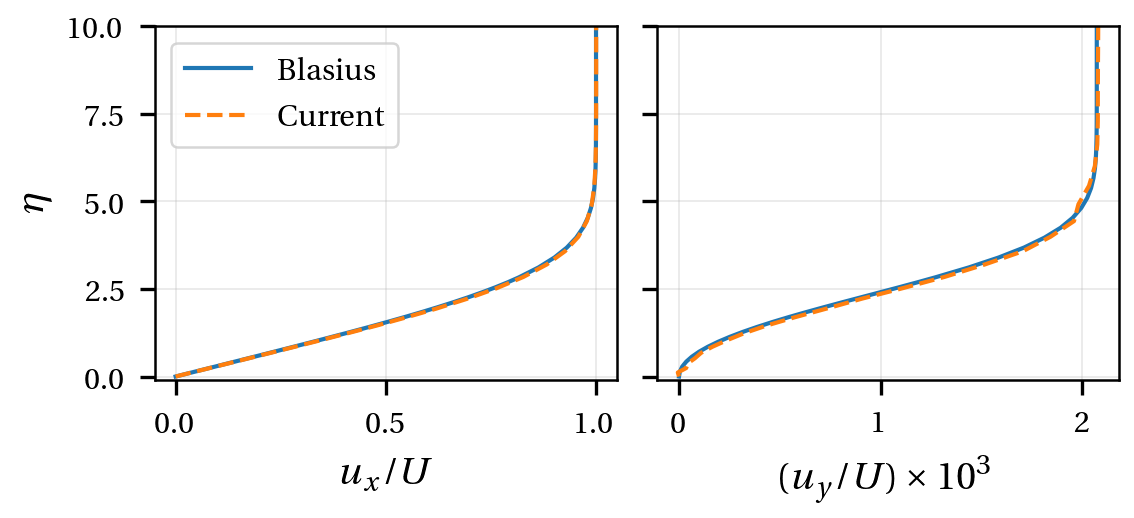

In [89]:
set_thesis_style()
fig, ax = create_figure(fraction=0.75, aspect_ratio=1.1, subplots=(1, 2), sharey=True)

for key, data in datas.items():
    ni = data['x'].shape[0]
    iCheck = 2*ni//3

    U = data['Velocity X'][iCheck, -1, 0]
    y = data['y'][iCheck, :, 0]
    x = data['x'][iCheck, :, 0]
    etaFlow = y / (nu * x / U)**0.5
    ublausius = U * dfdeta
    vblausius = 0.5 * (U * nu / x[iCheck]) ** 0.5 * eta_dfdeta_minusf
    
    if key==0:
        ax[0].plot(ublausius/U, eta, label='Blasius')
        ax[1].plot(vblausius/U*1000, eta)
    ax[0].plot(data['Velocity X'][iCheck, :, 0]/U, etaFlow, lstyles[key], mfc='none',label=labels[key])
    ax[1].plot(data['Velocity Y'][iCheck, :, 0]/U*1000, etaFlow, lstyles[key], mfc='none')


# fig.legend(ncol=len(input_filenames)+1, bbox_to_anchor=(0.5, 1.1), loc='upper center')
ax[0].legend()
ax[0].set_ylabel(r'$\eta$')
ax[0].set_xlabel(r'$u_x/U$')
ax[0].grid(alpha=0.3)

ax[1].set_xlabel(r'$(u_y/U) \times 10^3$')
ax[1].grid(alpha=0.3)

ax[0].set_ylim(-0.1, 10)
ax[1].set_ylim(-0.1, 10)

fig.savefig('flatplate_results_comparison.pdf')


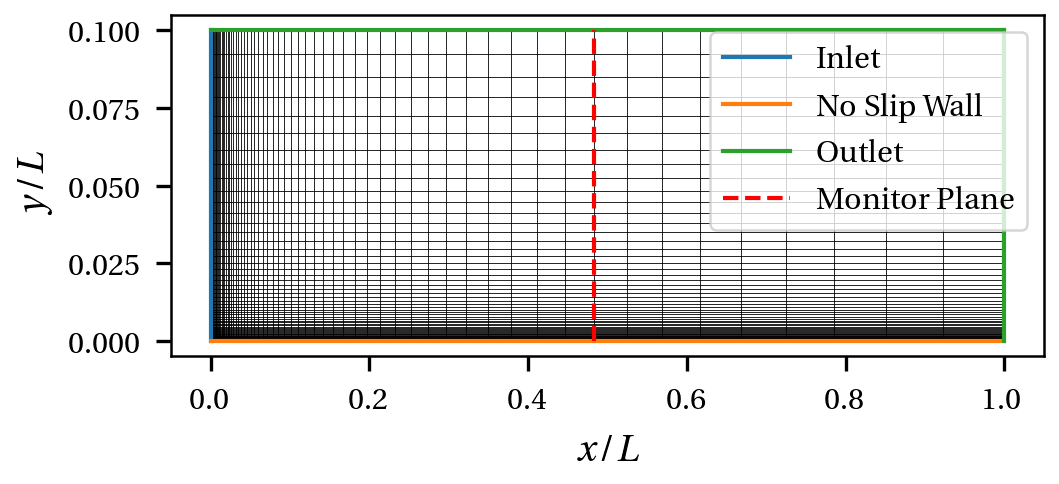

In [90]:
fig, ax = create_figure(fraction=0.7, aspect_ratio=2.2, subplots=(1, 1))


ni,nj,nk = data['x'].shape
for i in range(1, ni-1):
    ax.plot(data['x'][i, :, 0]/L, data['y'][i, :, 0]/L, 'k', lw=0.2)
for j in range(1, nj-1):
    ax.plot(data['x'][:, j, 0]/L, data['y'][:, j, 0]/L, 'k', lw=0.2)

ax.plot(data['x'][0, :, 0]/L, data['y'][0, :, 0]/L, 'C0', label='Inlet')
ax.plot(data['x'][:, 0, 0]/L, data['y'][:, 0, 0]/L, 'C1', label='No Slip Wall')
ax.plot(data['x'][:, -1, 0]/L, data['y'][:, -1, 0]/L, 'C2', label='Outlet')
ax.plot(data['x'][-1, :, 0]/L, data['y'][-1, :, 0]/L, 'C2')
iCheck = np.argmin(np.abs(data['x'][:, 0, 0]-xComparison))
ax.plot(data['x'][iCheck, :, 0]/L, data['y'][-1, :, 0]/L, '--r', label='Monitor Plane')


ax.set_xlabel(r'$x/L$')
ax.set_ylabel(r'$y/L$')


ax.legend()
fig.savefig('flatplate_grid.pdf')